Étudiant : Tasnim Marzouki
ID Étudiant : 300145940
Cours : Techniques des Systèmes Informatiques (TSI) — INF1102-201-26H-03
Collège : Collège Boréal — Campus Toronto

# Rapport de surveillance et de performance d’un serveur Nginx

## Objectif
Ce projet consiste à analyser un fichier de logs d’un serveur web Nginx afin de surveiller son activité et ses performances.

L’analyse permet d’identifier :
- les adresses IP les plus actives
- les pages les plus visitées
- les erreurs HTTP (404, 500, etc.)

In [ ]:
import re
from collections import Counter

with open("data/sample.log", "r") as f:
    lines = f.readlines()

ips = []
urls = []
codes = []

for line in lines:
    ip = re.search(r'^(\d{1,3}(?:\.\d{1,3}){3})', line)
    url = re.search(r'"GET ([^ ]+)', line)
    code = re.search(r'" (\d{3}) ', line)

    if ip:
        ips.append(ip.group(1))
    if url:
        urls.append(url.group(1))
    if code:
        codes.append(code.group(1))

top_ips = Counter(ips).most_common(5)
top_urls = Counter(urls).most_common(5)
code_counts = Counter(codes)

top_ips, top_urls, code_counts

## Résultats principaux

- Total requêtes : 10
- Total erreurs HTTP : 4
- Erreurs 404 : 2
- Erreurs 500 : 1

Ces résultats montrent que le serveur fonctionne majoritairement correctement, mais présente certaines erreurs à surveiller.

In [1]:
import re
from collections import Counter

with open("data/sample.log", "r") as f:
    lines = f.readlines()

ips = []
urls = []
codes = []

for line in lines:
    ip = re.search(r'^(\d{1,3}(?:\.\d{1,3}){3})', line)
    url = re.search(r'"GET ([^ ]+)', line)
    code = re.search(r'" (\d{3}) ', line)

    if ip:
        ips.append(ip.group(1))
    if url:
        urls.append(url.group(1))
    if code:
        codes.append(code.group(1))

In [2]:
from collections import Counter

top_ips = Counter(ips).most_common(5)
top_urls = Counter(urls).most_common(5)
code_counts = Counter(codes)

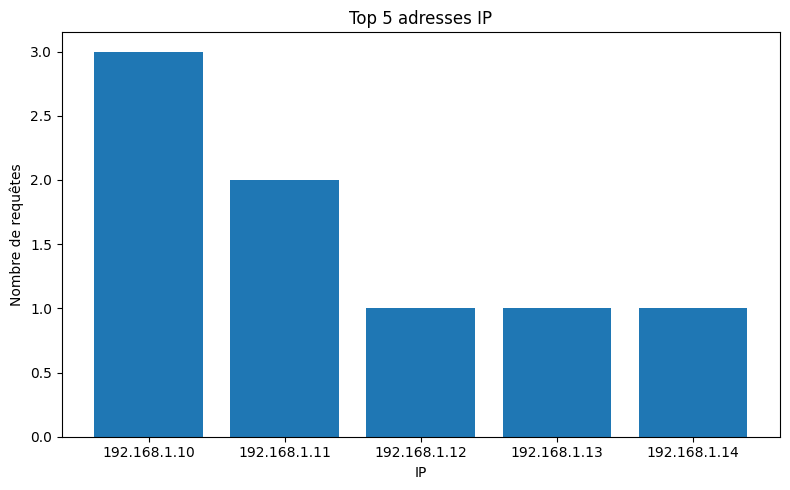

In [3]:
import matplotlib.pyplot as plt

ips_labels = [ip for ip, count in top_ips]
ips_values = [count for ip, count in top_ips]

plt.figure(figsize=(8,5))
plt.bar(ips_labels, ips_values)
plt.title("Top 5 adresses IP")
plt.xlabel("IP")
plt.ylabel("Nombre de requêtes")
plt.tight_layout()
plt.show()

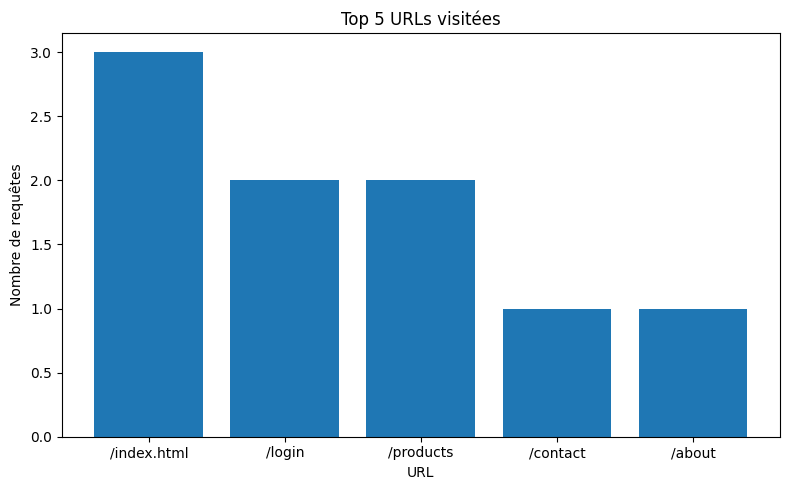

In [4]:
urls_labels = [url for url, count in top_urls]
urls_values = [count for url, count in top_urls]

plt.figure(figsize=(8,5))
plt.bar(urls_labels, urls_values)
plt.title("Top 5 URLs visitées")
plt.xlabel("URL")
plt.ylabel("Nombre de requêtes")
plt.tight_layout()
plt.show()

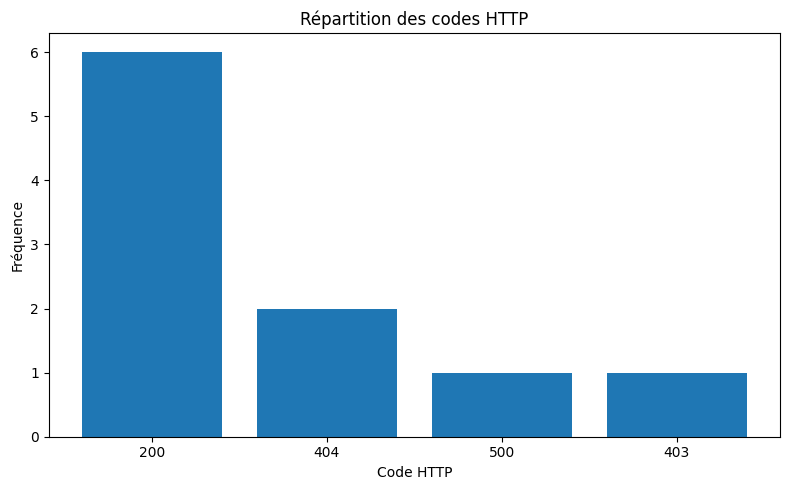

In [5]:
codes_labels = list(code_counts.keys())
codes_values = list(code_counts.values())

plt.figure(figsize=(8,5))
plt.bar(codes_labels, codes_values)
plt.title("Répartition des codes HTTP")
plt.xlabel("Code HTTP")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

## Visualisations

Les graphiques suivants présentent les adresses IP les plus actives, les URLs les plus visitées et la répartition des codes HTTP observés dans le fichier journal.

## Conclusion

Cette analyse permet de surveiller l’activité du serveur Nginx et de repérer rapidement les erreurs HTTP, les clients les plus actifs et les pages les plus demandées. Ce type de rapport peut être utile pour le monitoring, la performance et la sécurité.